In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv(r"C:\Users\SUMANTH GAJJELA\OneDrive\Desktop\COE 20.02.2026\Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [8]:
df.drop(['CustomerID','Gender'],axis=1,inplace=True)

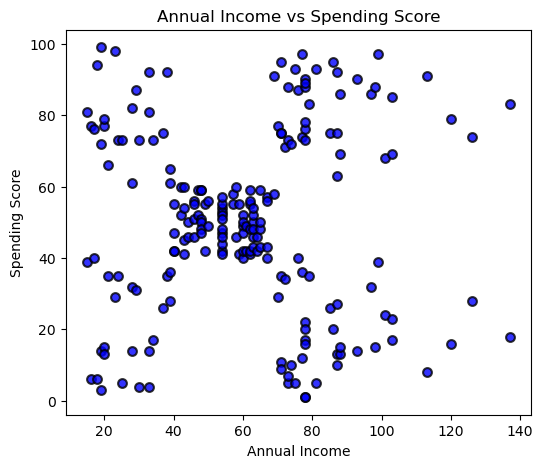

In [9]:
# EDA
# Annual income vs spending income using scatter plot

plt.figure(figsize=(6,5))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    color='blue',
    alpha=0.8,
    linewidths=1.5,   
    marker='o',       
    edgecolor='black',
    s=40               
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

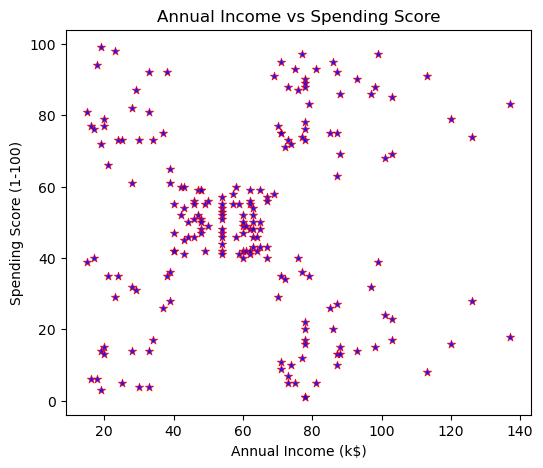

In [12]:
plt.figure(figsize=(6,5))

plt.scatter(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df,
    color='blue',
    alpha=0.9,
    linewidths=0.5,
    edgecolors='red',
    marker='*',
    s=40
)

plt.title("Annual Income vs Spending Score")
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [13]:
# Standard Scaler
from sklearn.preprocessing import StandardScaler

# create scaler object
scaler = StandardScaler()

# fit and transform data
scaled_data = scaler.fit_transform(df)
scaled_data

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992],
       [-1.20926872, -1.66266033,  1.00159627],
       [-0.27630176, -1.62449091, -1.71591298],
       [-1.13750203, -1.62449091,  1.70038436],
       [ 1.80493225, -1.58632148, -1.83237767],
       [-0.6351352 , -1.58632148,  0.84631002],
       [ 2.02023231, -1.58632148, -1.4053405 ],
       [-0.27630176, -1.58632148,  1.89449216],
       [ 1.37433211, -1.54815205, -1.36651894],
       [-1.06573534, -1.54815205,  1.04041783],
       [-0.13276838, -1.54815205, -1.44416206],
       [-1.20926872, -1.54815205,  1.11806095],
       [-0.27630176, -1.50998262, -0.59008772],
       [-1.3528021 , -1.50998262,  0.61338066],
       [ 0.94373197, -1.43364376, -0.82301709],
       [-0.27630176, -1.43364376,  1.8556706 ],
       [-0.27630176, -1.39547433, -0.590

In [14]:
# convert scaled data array into data frame

df=pd.DataFrame(scaled_data,columns=df.columns)
df

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980
...,...,...,...
195,-0.276302,2.268791,1.118061
196,0.441365,2.497807,-0.861839
197,-0.491602,2.497807,0.923953
198,-0.491602,2.917671,-1.250054


In [17]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select only required features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create model
model = KMeans(n_clusters=4, random_state=42)

# Train model
model.fit(X_scaled)

# Get cluster labels
labels = model.labels_

labels

C:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 0,
       0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [18]:
df['Clusters']=model.labels_
df.head()

,Age,Annual Income (k$),Spending Score (1-100),Clusters
0,-1.424569,-1.738999,-0.434801,0
1,-1.281035,-1.738999,1.195704,2
2,-1.352802,-1.700830,-1.715913,0
3,-1.137502,-1.700830,1.040418,2
4,-0.563369,-1.662660,-0.395980,0


In [19]:
#value counts of the clusters
df['Clusters'].value_counts()

Clusters
0    101
1     39
3     38
2     22
Name: count, dtype: int64

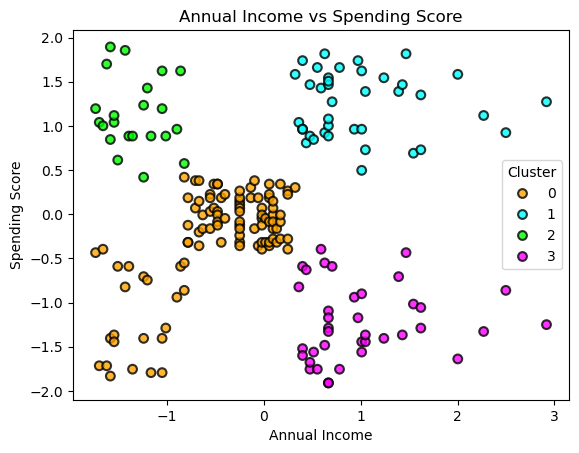

In [21]:
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Clusters',
    palette={0:'orange', 1:'cyan', 2:'lime', 3:'magenta'},
    alpha=0.8,
    linewidths=1.5,
    marker='o',
    edgecolor='black',
    s=40
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend(title="Cluster")
plt.show()

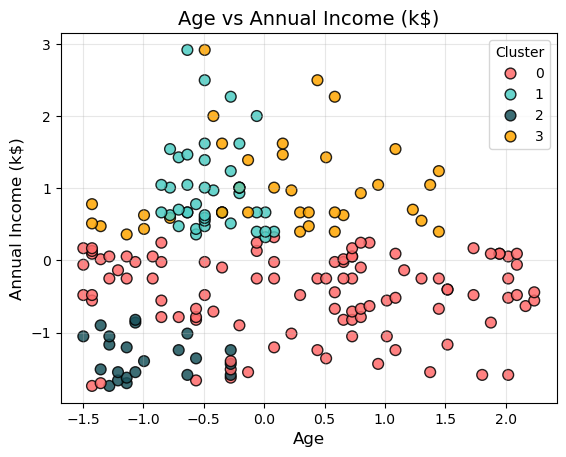

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x='Age',
    y='Annual Income (k$)',
    hue='Clusters',
    palette={0:'#FF6B6B', 1:'#4ECDC4', 2:'#1A535C', 3:'#FFA600'},
    alpha=0.85,
    linewidth=1,
    edgecolor='black',
    s=60
)

plt.title("Age vs Annual Income (k$)", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Annual Income (k$)", fontsize=12)
plt.legend(title="Cluster")
plt.grid(alpha=0.3)
plt.show()

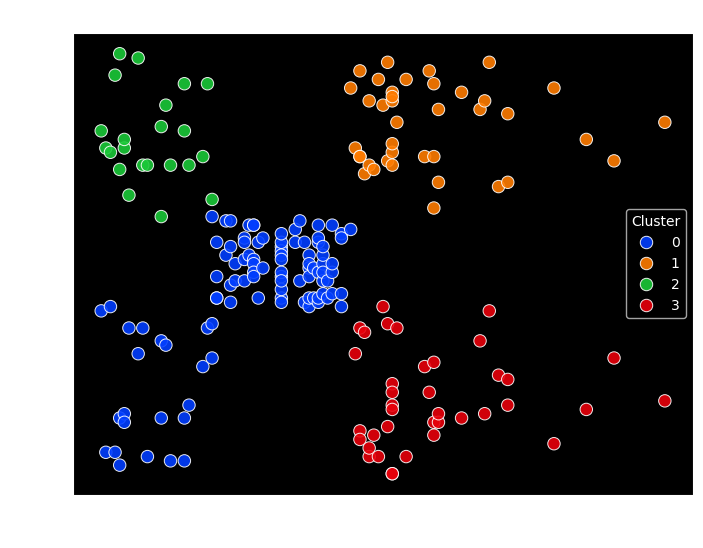

In [23]:
plt.figure(figsize=(8,6))
plt.style.use("dark_background")

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Clusters',
    palette='bright',
    s=80,
    edgecolor='white',
    alpha=0.9
)

plt.title("Customer Segments (Dark Theme)", fontsize=14)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.show()

C:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128181 (\N{BANKNOTE WITH DOLLAR SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


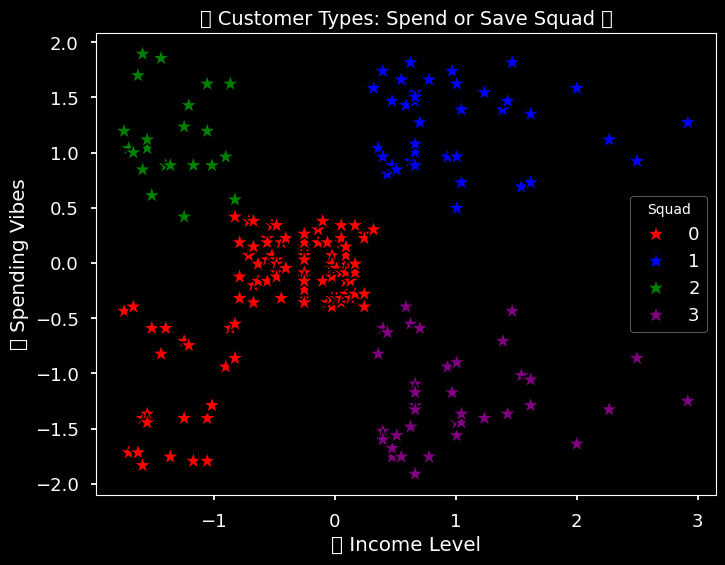

In [24]:
plt.figure(figsize=(8,6))
plt.style.use("seaborn-v0_8-talk")

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Clusters',
    palette=['red','blue','green','purple'],
    s=200,
    marker='*',
    edgecolor='black'
)

plt.title("🎯 Customer Types: Spend or Save Squad 💸", fontsize=14)
plt.xlabel("💵 Income Level")
plt.ylabel("🔥 Spending Vibes")
plt.legend(title="Squad")
plt.show()

C:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Clustering Evaluation Metrics:
--------------------------------
Silhouette Score: 0.5152707076078172
Davies-Bouldin Score: 0.6252320501581042
Calinski-Harabasz Score: 40.331642478090686


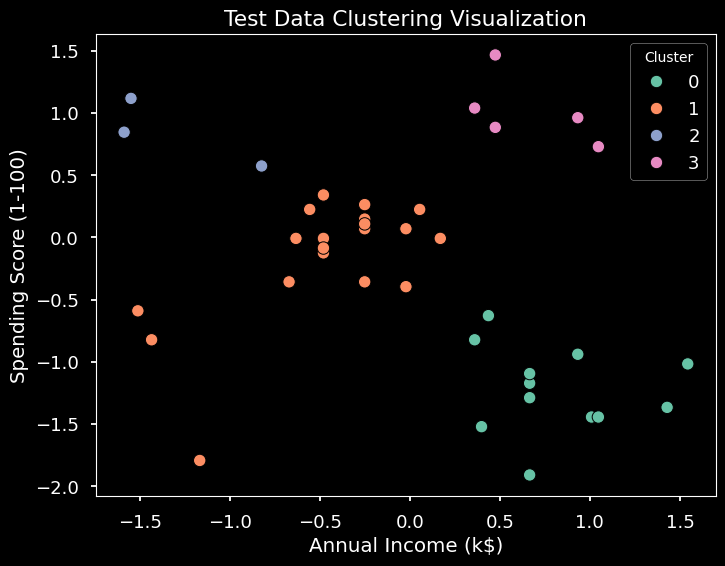

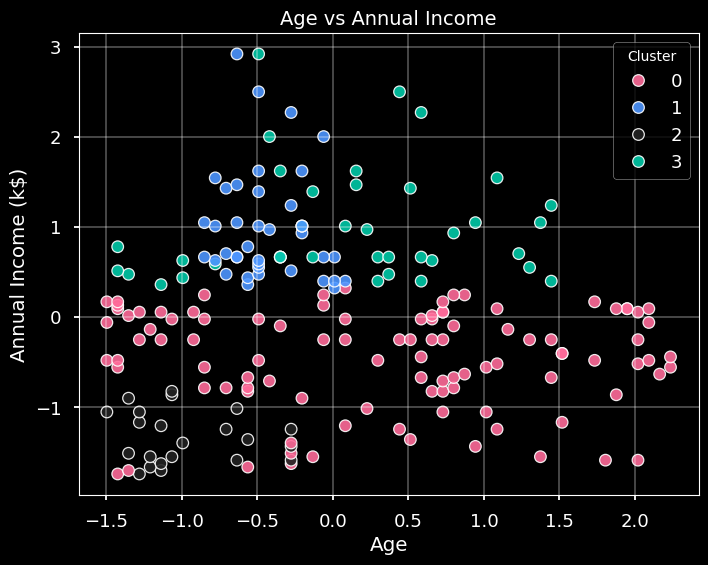

In [31]:
plt.figure(figsize=(8,6))

colours = ['#FF6B9A', '#4D96FF', '#222222', '#00C9A7']

sns.scatterplot(
    x='Age',
    y='Annual Income (k$)',
    hue='Clusters',   # ← FIXED HERE
    data=df,
    alpha=0.9,
    palette=colours,
    linewidths=0.9,
    edgecolor='white',
    s=70
)

plt.title("Age vs Annual Income", fontsize=14)
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.legend(title="Cluster")
plt.grid(alpha=0.3)
plt.show()

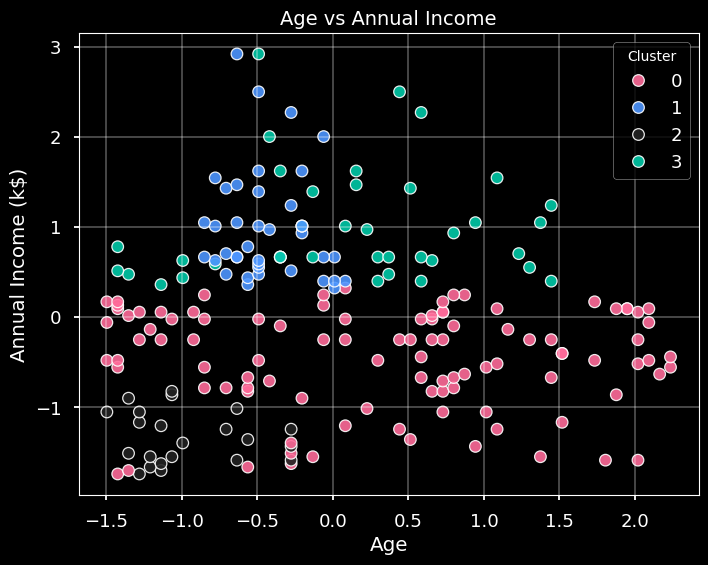

In [30]:
plt.figure(figsize=(8,6))

colours = ['#FF6B9A', '#4D96FF', '#222222', '#00C9A7']

sns.scatterplot(
    x='Age',
    y='Annual Income (k$)',
    hue='Clusters',   # ← FIXED HERE
    data=df,
    alpha=0.9,
    palette=colours,
    linewidths=0.9,
    edgecolor='white',
    s=70
)

plt.title("Age vs Annual Income", fontsize=14)
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.legend(title="Cluster")
plt.grid(alpha=0.3)
plt.show()

In [37]:
# =====================================
# Random Forest Classification
# =====================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1️⃣ Divide data into X and y
X = df.drop('Cluster', axis=1)   # Features
y = df['Cluster']                # Target

# 2️⃣ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3️⃣ Feature Scaling (optional for RF, but safe)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4️⃣ Train Random Forest Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# 5️⃣ Predict
y_pred = model.predict(X_test)

# 6️⃣ Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

KeyError: "['Cluster'] not found in axis"

In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Features and target
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
y = df['Clusters']

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = clf.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on test data:", round(accuracy, 3))

Accuracy on test data: 0.983


C:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

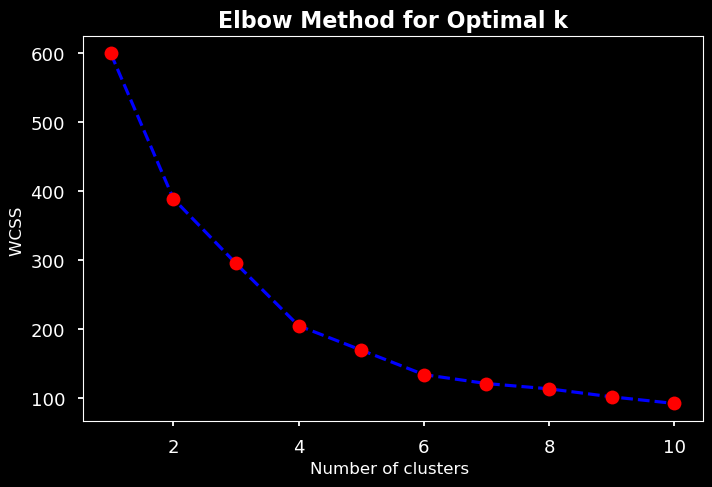

In [39]:
# check the elbow 
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot WCSS vs k with colors
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o', linestyle='--', color='blue', markerfacecolor='red', markersize=10)
plt.title("Elbow Method for Optimal k", fontsize=16, fontweight='bold')
plt.xlabel("Number of clusters ", fontsize=12)
plt.ylabel("WCSS ", fontsize=12)
plt.show()

C:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

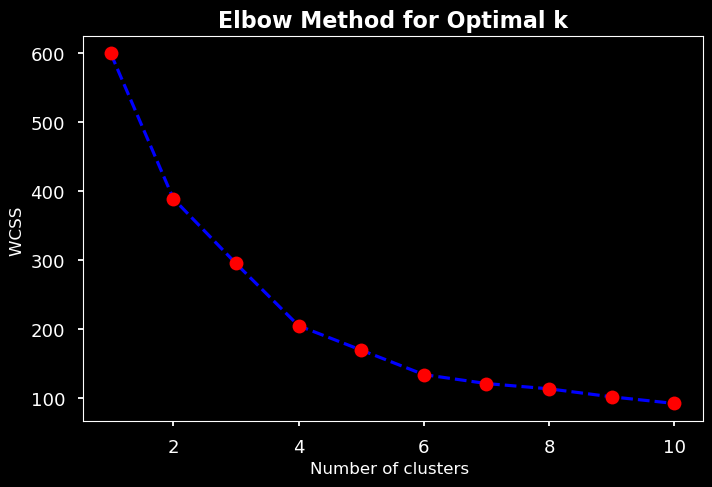

In [40]:
# check the elbow 
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot WCSS vs k with colors
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o', linestyle='--', color='blue', markerfacecolor='red', markersize=10)
plt.title("Elbow Method for Optimal k", fontsize=16, fontweight='bold')
plt.xlabel("Number of clusters ", fontsize=12)
plt.ylabel("WCSS ", fontsize=12)
plt.show()

In [41]:
# Save the trained model
import joblib
joblib.dump(clf, 'Random_Forest_model.pkl')

['Random_Forest_model.pkl']

In [42]:
#save the dataset
df.to_csv('clustered_data.csv',index=False)

In [43]:
# saved the k-means model
joblib.dump(model,'Kmeans_model.pkl')

['Kmeans_model.pkl']